# Imports

In [65]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.gamma_gompertz import GammaGompertz as gg
from ageing_packages.hetero_analysis import nhanes_analysis as nhanes


import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter
import sklearn.preprocessing as skp


# Suppress lifelines approximation warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lifelines')
warnings.filterwarnings('ignore', message='.*Approximating using.*survival_function_.*')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:

mort = pd.read_csv("nhanes/nhanes_mortality_all_years.csv")

# ---- 1. read age data ----
age = pd.read_csv("nhanes/all_cohort_age_data.csv",
                  usecols=["SEQN", "age_in_years", "age_at_screening"])

# ---- 2. filter mortality data ----
mort = mort[mort["eligstat"] == 1]  # keep only linkage-eligible

# ---- 3. merge all data ----
core = age.merge(mort, on="SEQN")

# ---- 4. construct entry/exit/event ----
core["entry_age"] = core["age_in_years"].fillna(core["age_at_screening"]).astype(float)
core["exit_age"] = core["entry_age"] + core["permth_int"] / 12.0
core["event"] = core["mortstat"]
def plot_baseline_km(ax):
    """
    Plot the Kaplan-Meier curve for the baseline (all cohort) in black.
    
    Args:
        ax: matplotlib axes object to plot on
    """
    kmf = KaplanMeierFitter()
    
    # Create a timeline with higher resolution to reduce approximation warnings
    
    # Check if required columns exist before fitting
    required_cols = ['exit_age', 'event', 'entry_age']
    missing_cols = [col for col in required_cols if col not in core.columns]
    
    if missing_cols:
        print(f"Missing required columns: {missing_cols}")
        print(f"Available columns: {core.columns.tolist()}")
        return None
    
    # Fit the baseline curve for all participants
    kmf.fit(
        durations=core["exit_age"],
        event_observed=core["event"],
        entry=core["entry_age"],
        label="Baseline (All)",
    )
    
    # Plot in black
    kmf.plot_survival_function(ax=ax, color='black', linewidth=2)
    
    return kmf


# puberty


In [71]:

df_A = pd.read_sas('nhanes/reproductive_health/RHQ.xpt' , format = 'xport')
df_B = pd.read_sas('nhanes/reproductive_health/RHQ_B.xpt' , format = 'xport')
df_C = pd.read_sas('nhanes/reproductive_health/RHQ_C.xpt' , format = 'xport')
df_D = pd.read_sas('nhanes/reproductive_health/RHQ_D.xpt' , format = 'xport')
df_E = pd.read_sas('nhanes/reproductive_health/RHQ_E.xpt' , format = 'xport')
df_F = pd.read_sas('nhanes/reproductive_health/RHQ_F.xpt' , format = 'xport')
df_G = pd.read_sas('nhanes/reproductive_health/RHQ_G.xpt' , format = 'xport')
df_H = pd.read_sas('nhanes/reproductive_health/RHQ_H.xpt' , format = 'xport')
df_I = pd.read_sas('nhanes/reproductive_health/RHQ_I.xpt' , format = 'xport')
df_J = pd.read_sas('nhanes/reproductive_health/RHQ_J.xpt' , format = 'xport')

# Combine all diet dataframes keeping only SEQN and DBQ700 columns
df = pd.concat([
    df_D[['SEQN', 'RHQ010']],
    df_E[['SEQN', 'RHQ010']], 
    df_F[['SEQN', 'RHQ010']],
    df_G[['SEQN', 'RHQ010']],
    df_H[['SEQN', 'RHQ010']],
    df_I[['SEQN', 'RHQ010']],
    df_J[['SEQN', 'RHQ010']]
], axis=0).reset_index(drop=True)

# Drop rows where RHQ010 is missing, non-numeric, or outside valid range (8-25)
df = df.dropna(subset=['RHQ010'])
df = df[pd.to_numeric(df['RHQ010'], errors='coerce').notna()]
df['RHQ010'] = pd.to_numeric(df['RHQ010'])
df = df[(df['RHQ010'] >= 5) & (df['RHQ010'] <= 25)]



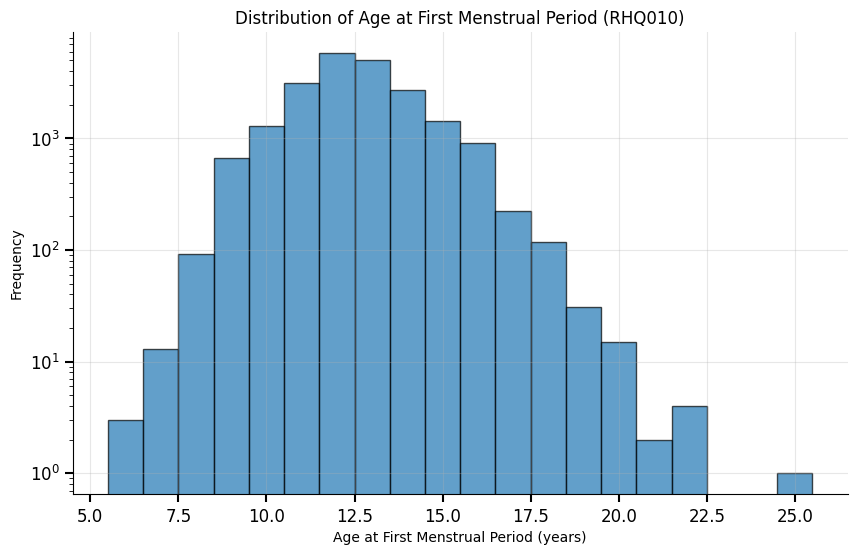

Mean: 12.58
Median: 12.00
Std: 1.74
Min: 6.00
Max: 25.00
Count (non-null): 21532


In [74]:
# Plot distribution of RHQ010 (age at first menstrual period)
plt.figure(figsize=(10, 6))
# Create integer-sized bins centered around integer values (e.g., 10, 11, 12)
min_age = int(df['RHQ010'].min())
max_age = int(df['RHQ010'].max()) + 1
bins = np.arange(min_age - 0.5, max_age + 0.5, 1)
plt.hist(df['RHQ010'].dropna(), bins=bins, edgecolor='black', alpha=0.7)
plt.xlabel('Age at First Menstrual Period (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Age at First Menstrual Period (RHQ010)')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# Print summary statistics
print(f"Mean: {df['RHQ010'].mean():.2f}")
print(f"Median: {df['RHQ010'].median():.2f}")
print(f"Std: {df['RHQ010'].std():.2f}")
print(f"Min: {df['RHQ010'].min():.2f}")
print(f"Max: {df['RHQ010'].max():.2f}")
print(f"Count (non-null): {df['RHQ010'].count()}")

In [83]:
df_puberty = core.merge(df.dropna(subset=["RHQ010"]), on="SEQN")

# ---- 4. construct entry/exit/event ----
df_puberty["entry_age"] = df_puberty["age_in_years"].fillna(df_puberty["age_at_screening"]).astype(float)
df_puberty["exit_age"] = df_puberty["entry_age"] + df_puberty["permth_int"] / 12.0
df_puberty["event"] = df_puberty["mortstat"]

# ---- 5. Define function to plot hazard or survival curves for age at menarche ranges ----
from lifelines import NelsonAalenFitter

def plot_menarche_curves(age_range, ax=None, curve_type='hazard', bandwidth=3, label=None, scaled=False):
    """
    Plot hazard, cumulative hazard, or survival curves for participants with age at menarche in specified range.
    
    Parameters:
    -----------
    age_range : int or tuple
        If int, selects participants with that exact age at menarche.
        If tuple (min, max), selects participants with age at menarche in [min, max] inclusive.
    ax : matplotlib axis, optional
        Axis to plot on. If None, creates new figure.
    curve_type : str, default='hazard'
        Type of curve to plot: 'hazard', 'cum_hazard', or 'survival'
    bandwidth : float, default=3
        Bandwidth for smoothing hazard curve
    label : str, optional
        Label for the curve. If None, auto-generates from age_range.
    scaled : bool, default=False
        If True and curve_type='survival', plot survival vs timeline/median_lifespan
    
    Returns:
    --------
    ax : matplotlib axis
        The axis with the plot
    """
    # Parse age_range
    if isinstance(age_range, int):
        subset = df_puberty[df_puberty["RHQ010"] == age_range]
        age_label = f"Age {age_range}"
    elif isinstance(age_range, (tuple, list)) and len(age_range) == 2:
        min_age, max_age = age_range
        subset = df_puberty[(df_puberty["RHQ010"] >= min_age) & (df_puberty["RHQ010"] <= max_age)]
        age_label = f"Age {min_age}-{max_age}"
    else:
        raise ValueError("age_range must be an integer or tuple of (min, max)")
    
    # Filter out rows with NaN entry_age or exit_age
    subset = subset.dropna(subset=["entry_age", "exit_age"])
    
    if len(subset) == 0:
        print(f"No participants in age range {age_range}")
        return ax
    
    # Calculate n and n_deaths
    n = len(subset)
    n_deaths = subset["event"].sum()
    
    # Generate label if not provided
    if label is None:
        label = f"{age_label} (n={n}, n_deaths={n_deaths})"
    else:
        label = f"{label} (n={n}, n_deaths={n_deaths})"
    
    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create timeline with higher resolution
    timeline = np.linspace(20, 120, 1000)
    
    if curve_type == 'hazard':
        # Use NelsonAalenFitter for cumulative hazard, then plot smoothed hazard
        naf = NelsonAalenFitter()
        naf.fit(
            durations=subset["exit_age"],
            event_observed=subset["event"],
            entry=subset["entry_age"],
            timeline=timeline
        )
        naf.plot_hazard(ax=ax, bandwidth=bandwidth, label=label)
        
    elif curve_type == 'cum_hazard':
        # Use NelsonAalenFitter for cumulative hazard
        timeline = np.linspace(60, 120, 1000)
        naf = NelsonAalenFitter()
        naf.fit(
            durations=subset["exit_age"],
            event_observed=subset["event"],
            entry=subset["entry_age"],
            timeline=timeline
        )
        naf.plot_cumulative_hazard(ax=ax, label=label)
        
    elif curve_type == 'survival':
        # Use KaplanMeierFitter for survival curve
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=subset["exit_age"],
            event_observed=subset["event"],
            entry=subset["entry_age"],
            label=label,
            timeline=timeline
        )
        
        if scaled:
            # Calculate median lifespan
            median_lifespan = kmf.median_survival_time_
            # Plot scaled survival curve
            ax.plot(timeline / median_lifespan, kmf.survival_function_at_times(timeline), label=label)
            ax.set_xlabel(r'$\frac{t}{t_m}$')
            ax.set_xlim(0, 2)
        else:
            kmf.plot_survival_function(ax=ax)
    else:
        raise ValueError("curve_type must be 'hazard', 'cum_hazard', or 'survival'")
    
    return ax


def compare_menarche_survival(group1, group2, alpha=0.05):
    """
    Perform log-rank test to compare survival curves between two menarche age groups.
    
    Parameters:
    -----------
    group1 : tuple
        (min_age, max_age) for first menarche age group
    group2 : tuple
        (min_age, max_age) for second menarche age group
    alpha : float
        Significance level for the test (default: 0.05)
    
    Returns:
    --------
    dict : Dictionary containing test results
    """
    from lifelines.statistics import logrank_test
    
    # Filter data for group 1 based on menarche age (RHQ010)
    subset1 = df_puberty[
        (df_puberty["RHQ010"] >= group1[0]) & 
        (df_puberty["RHQ010"] <= group1[1])
    ]
    subset1 = subset1.dropna(subset=["entry_age", "exit_age"])
    
    # Filter data for group 2 based on menarche age (RHQ010)
    subset2 = df_puberty[
        (df_puberty["RHQ010"] >= group2[0]) & 
        (df_puberty["RHQ010"] <= group2[1])
    ]
    subset2 = subset2.dropna(subset=["entry_age", "exit_age"])
    
    # Perform log-rank test
    results = logrank_test(
        durations_A=subset1["exit_age"],
        durations_B=subset2["exit_age"],
        event_observed_A=subset1["event"],
        event_observed_B=subset2["event"],
        alpha=alpha
    )
    
    # Print results
    print(f"Log-Rank Test: Group {group1} vs Group {group2}")
    print("=" * 60)
    print(f"Test statistic: {results.test_statistic:.4f}")
    print(f"p-value: {results.p_value:.6f}")
    print(f"Significance level (α): {alpha}")
    
    if results.p_value < alpha:
        print(f"Result: REJECT null hypothesis (p < {alpha})")
        print("Conclusion: The survival curves are significantly different.")
    else:
        print(f"Result: FAIL TO REJECT null hypothesis (p >= {alpha})")
        print("Conclusion: No significant difference between survival curves.")
    
    print("=" * 60)
    print(f"Group 1 ({group1}): n = {len(subset1)}, events = {subset1['event'].sum()}")
    print(f"Group 2 ({group2}): n = {len(subset2)}, events = {subset2['event'].sum()}")
    print()
    
    return {
        'test_statistic': results.test_statistic,
        'p_value': results.p_value,
        'is_significant': results.p_value < alpha,
        'n_group1': len(subset1),
        'n_group2': len(subset2),
        'events_group1': subset1['event'].sum(),
        'events_group2': subset2['event'].sum()
    }


def calculate_steepness(age_range):
    """
    Calculate the steepness of the survival curve for a given menarche age range.
    
    Steepness is defined as: median_lifespan / IQR
    where IQR = (time at 25% survival) - (time at 75% survival)
    
    Parameters:
    -----------
    age_range : tuple
        (min_age, max_age) for menarche age range
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'steepness': median_lifespan / IQR
        - 'median_lifespan': median survival time
        - 'q75_time': time when survival is 0.75
        - 'q25_time': time when survival is 0.25
        - 'IQR': Interquartile range (q25_time - q75_time)
    """
    # Filter data for the specified menarche age range
    subset = df_puberty[
        (df_puberty["RHQ010"] >= age_range[0]) & 
        (df_puberty["RHQ010"] <= age_range[1])
    ]
    subset = subset.dropna(subset=["entry_age", "exit_age"])
    
    # Fit Kaplan-Meier
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"]
    )
    
    # Get median lifespan
    median_lifespan = kmf.median_survival_time_
    
    # Get times for 75% and 25% survival
    # percentile method returns the time at which survival drops to that level
    q75_time = kmf.percentile(0.75)
    q25_time = kmf.percentile(0.25)
    
    # Calculate IQR
    IQR = q25_time - q75_time
    
    # Calculate steepness
    steepness = median_lifespan / IQR if IQR > 0 else np.nan
    
    return {
        'steepness': steepness,
        'median_lifespan': median_lifespan,
        'q75_time': q75_time,
        'q25_time': q25_time,
        'IQR': IQR,
        'n': len(subset),
        'events': subset['event'].sum()
    }


In [84]:
# Define age groups
group_early = (4, 10)
group_mid = (12, 14)
group_late = (16, 25)

# Calculate steepness for each group
results_early = calculate_steepness(group_early)
results_mid = calculate_steepness(group_mid)
results_late = calculate_steepness(group_late)

# Print results
print("Steepness Analysis:")
print("=" * 60)
print(f"\nEarly group ({group_early[0]}-{group_early[1]} years):")
print(f"  Steepness: {results_early['steepness']:.3f}")
print(f"  Median lifespan: {results_early['median_lifespan']:.2f} years")
print(f"  n={results_early['n']}, events={results_early['events']}")

print(f"\nMid group ({group_mid[0]}-{group_mid[1]} years):")
print(f"  Steepness: {results_mid['steepness']:.3f}")
print(f"  Median lifespan: {results_mid['median_lifespan']:.2f} years")
print(f"  n={results_mid['n']}, events={results_mid['events']}")

print(f"\nLate group ({group_late[0]}-{group_late[1]} years):")
print(f"  Steepness: {results_late['steepness']:.3f}")
print(f"  Median lifespan: {results_late['median_lifespan']:.2f} years")
print(f"  n={results_late['n']}, events={results_late['events']}")

print("\nRatios:")
print(f"  Steepness ratio (Early/Mid): {results_early['steepness'] / results_mid['steepness']:.3f}")
print(f"  Median lifespan ratio (Early/Mid): {results_early['median_lifespan'] / results_mid['median_lifespan']:.3f}")


Steepness Analysis:

Early group (4-10 years):
  Steepness: 5.087
  Median lifespan: 82.67 years
  n=1631, events=113.0

Mid group (12-14 years):
  Steepness: 5.801
  Median lifespan: 85.08 years
  n=11654, events=975.0

Late group (16-25 years):
  Steepness: 5.101
  Median lifespan: 84.58 years
  n=1300, events=145.0

Ratios:
  Steepness ratio (Early/Mid): 0.877
  Median lifespan ratio (Early/Mid): 0.972


## plotting


Log-Rank Test Results:
Log-Rank Test: Group (4, 10) vs Group (12, 14)
Test statistic: 15.7626
p-value: 0.000072
Significance level (α): 0.05
Result: REJECT null hypothesis (p < 0.05)
Conclusion: The survival curves are significantly different.
Group 1 ((4, 10)): n = 1631, events = 113.0
Group 2 ((12, 14)): n = 11654, events = 975.0

Log-Rank Test: Group (4, 10) vs Group (16, 25)
Test statistic: 6.3827
p-value: 0.011524
Significance level (α): 0.05
Result: REJECT null hypothesis (p < 0.05)
Conclusion: The survival curves are significantly different.
Group 1 ((4, 10)): n = 1631, events = 113.0
Group 2 ((16, 25)): n = 1300, events = 145.0

Log-Rank Test: Group (12, 14) vs Group (16, 25)
Test statistic: 1.1494
p-value: 0.283680
Significance level (α): 0.05
Result: FAIL TO REJECT null hypothesis (p >= 0.05)
Conclusion: No significant difference between survival curves.
Group 1 ((12, 14)): n = 11654, events = 975.0
Group 2 ((16, 25)): n = 1300, events = 145.0



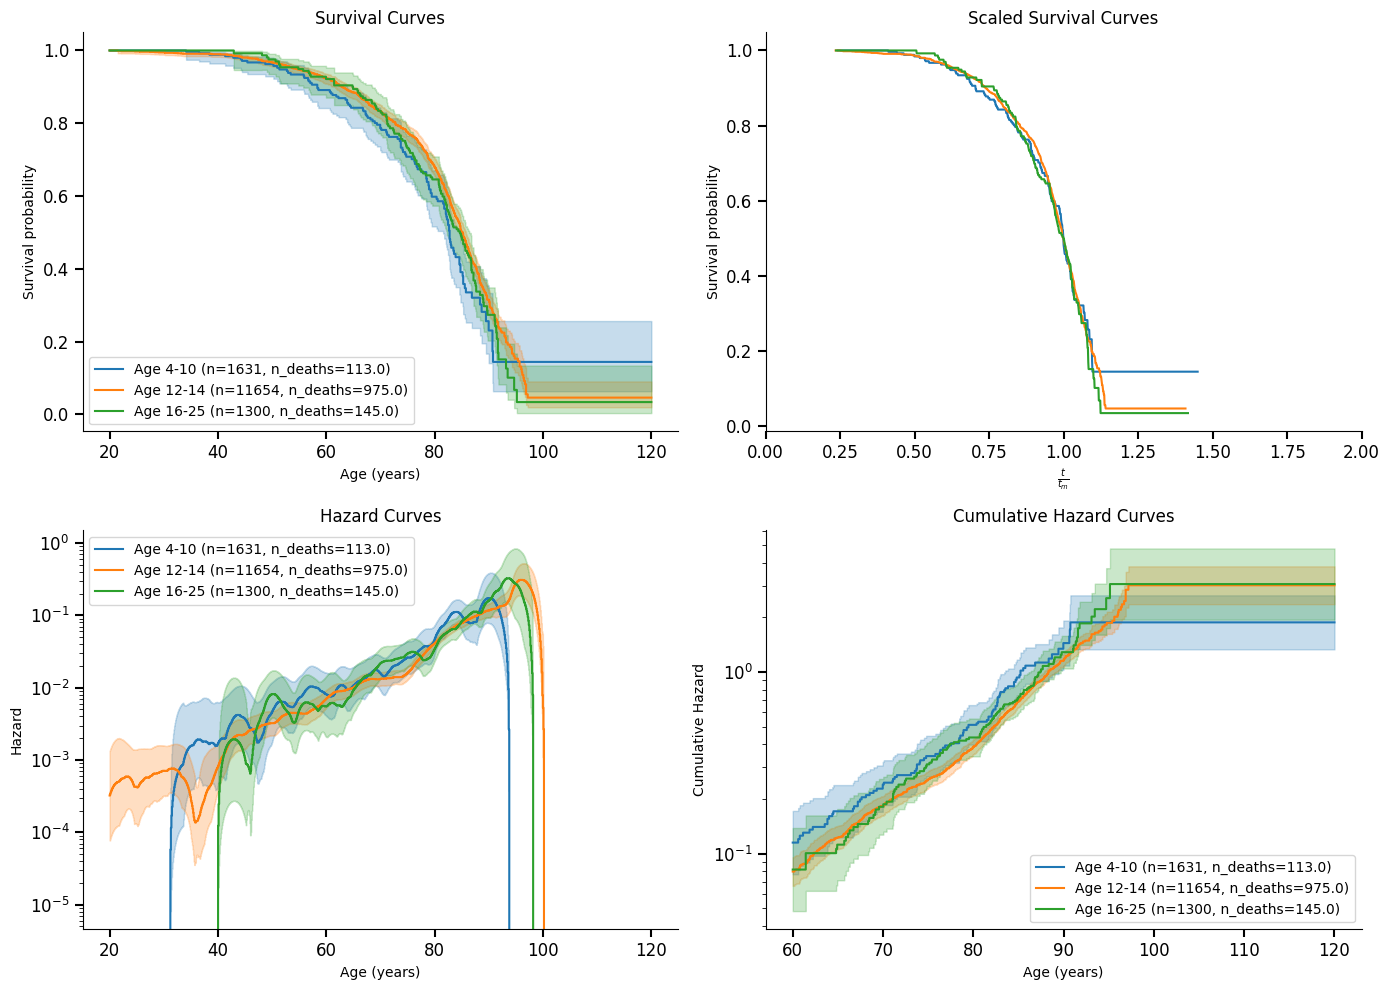

In [82]:
# Define age groups
group_early = (4, 10)
group_mid = (12, 14)
group_late = (16, 25)

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Upper left: Survival curves
plot_menarche_curves(group_early, ax=axes[0, 0], curve_type='survival', scaled=False)
plot_menarche_curves(group_mid, ax=axes[0, 0], curve_type='survival', scaled=False)
plot_menarche_curves(group_late, ax=axes[0, 0], curve_type='survival', scaled=False)
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].set_ylabel("Survival probability")
axes[0, 0].set_title("Survival Curves")

# Perform log-rank tests between groups
print("\nLog-Rank Test Results:")
print("=" * 60)
compare_menarche_survival(group_early, group_mid)
compare_menarche_survival(group_early, group_late)
compare_menarche_survival(group_mid, group_late)

# Upper right: Scaled survival curves
plot_menarche_curves(group_early, ax=axes[0, 1], curve_type='survival', scaled=True)
plot_menarche_curves(group_mid, ax=axes[0, 1], curve_type='survival', scaled=True)
plot_menarche_curves(group_late, ax=axes[0, 1], curve_type='survival', scaled=True)
axes[0, 1].set_xlabel(r'$\frac{t}{t_m}$')
axes[0, 1].set_ylabel("Survival probability")
axes[0, 1].set_title("Scaled Survival Curves")

# Lower left: Hazard curves
plot_menarche_curves(group_early, ax=axes[1, 0], curve_type='hazard')
plot_menarche_curves(group_mid, ax=axes[1, 0], curve_type='hazard')
plot_menarche_curves(group_late, ax=axes[1, 0], curve_type='hazard')
axes[1, 0].set_xlabel("Age (years)")
axes[1, 0].set_ylabel("Hazard")
axes[1, 0].set_yscale('log')
axes[1, 0].set_title("Hazard Curves")

# Lower right: Cumulative hazard curves
plot_menarche_curves(group_early, ax=axes[1, 1], curve_type='cum_hazard')
plot_menarche_curves(group_mid, ax=axes[1, 1], curve_type='cum_hazard')
plot_menarche_curves(group_late, ax=axes[1, 1], curve_type='cum_hazard')
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Cumulative Hazard")
axes[1, 1].set_title("Cumulative Hazard Curves")
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

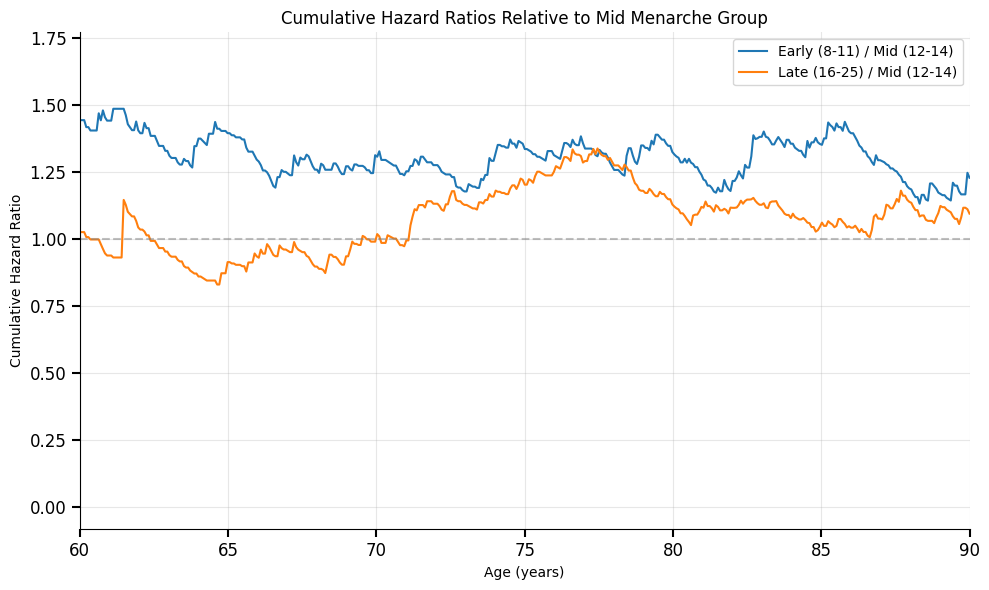

In [77]:
# Plot cumulative hazard ratios for early/mid and late/mid groups
timeline = np.linspace(20, 90, 1000)

# Fit NAF for each group
groups = {
    'early': (4, 10),
    'mid': (12, 14),
    'late': (16, 25)
}

nafs = {}
for name, (min_age, max_age) in groups.items():
    subset = df_puberty[(df_puberty["RHQ010"] >= min_age) & (df_puberty["RHQ010"] <= max_age)]
    subset = subset.dropna(subset=["entry_age", "exit_age"])
    
    naf = NelsonAalenFitter()
    naf.fit(
        durations=subset["exit_age"],
        event_observed=subset["event"],
        entry=subset["entry_age"],
        timeline=timeline
    )
    nafs[name] = naf

# Calculate cumulative hazards
cum_hazards = {name: naf.cumulative_hazard_at_times(timeline).values.flatten() 
               for name, naf in nafs.items()}

# Calculate ratios
ratio_early_mid = cum_hazards['early'] / cum_hazards['mid']
ratio_late_mid = cum_hazards['late'] / cum_hazards['mid']

# Plot both ratios
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timeline, ratio_early_mid, label='Early (8-11) / Mid (12-14)')
ax.plot(timeline, ratio_late_mid, label='Late (16-25) / Mid (12-14)')
ax.set_xlabel("Age (years)")
ax.set_ylabel("Cumulative Hazard Ratio")
ax.set_title("Cumulative Hazard Ratios Relative to Mid Menarche Group")
ax.axhline(y=1, color='grey', linestyle='--', alpha=0.5)
ax.set_xlim(60, 90)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


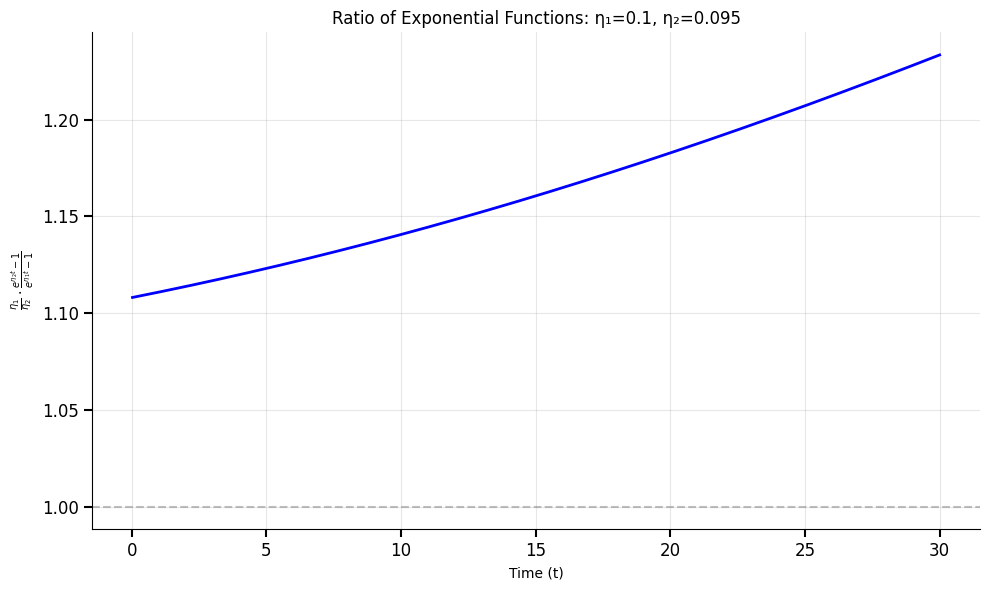

In [61]:
# Plot the ratio of exponential functions with given eta values
eta_1 = 0.1
eta_2 = 0.095

# Create timeline from 0 to 30
timeline_exp = np.linspace(0, 30, 1000)

# Calculate the ratio: eta_1/eta_2 * (e^(eta_2*t) - 1) / (e^(eta_1*t) - 1)
ratio_exp = (eta_1 / eta_2) * (np.exp(eta_1 * timeline_exp) - 1) / (np.exp(eta_2 * timeline_exp) - 1)

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(timeline_exp, ratio_exp, 'b-', linewidth=2)
ax.set_xlabel("Time (t)")
ax.set_ylabel(r"$\frac{\eta_1}{\eta_2} \cdot \frac{e^{\eta_2 t} - 1}{e^{\eta_1 t} - 1}$")
ax.set_title(f"Ratio of Exponential Functions: η₁={eta_1}, η₂={eta_2}")
ax.axhline(y=1, color='grey', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
